# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы: 
- Вы **сами** решаете, что <font color="#d18753">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

In [1]:
from sklearn.linear_model import LogisticRegression
from pipeline_base import run_base_pipeline
import pandas as pd
import re
from functools import lru_cache
import nltk
from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords
import pymorphy3
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler
from pipeline_base import (
    build_hero_matrices,
    fit_region_mmr_artifacts,
    transform_region_mmr,
)


def gini(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) - 1


best_logreg = {
    "solver": "lbfgs",
    "C": 1.2542627009984555,
    "max_iter": 1600,
    "random_state": 42,
}


def make_best_logreg(**overrides):
    params = {**best_logreg, **overrides}
    return LogisticRegression(**params)


base_result = run_base_pipeline(
    data_dir="dota-2-hse-ml-1-course-competition-2026",
    model_params=best_logreg,
    submission_path="submission_base_all_features.csv",
)


### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [2]:
chat_df = pd.read_csv("dota-2-hse-ml-1-course-competition-2026/game_chat.csv")
print(chat_df.shape)
display(
    chat_df[chat_df["radiant_chat"].notna() | chat_df["dire_chat"].notna()].sample(5)
)

n = len(chat_df)
r_empty = (chat_df["radiant_chat"].fillna("") == "").sum()
d_empty = (chat_df["dire_chat"].fillna("") == "").sum()
both_empty = (
    (chat_df["radiant_chat"].fillna("") == "") & (chat_df["dire_chat"].fillna("") == "")
).sum()

print(f"missing radiant_chat: {r_empty / n:.2%}")
print(f"missing dire_chat:\t   {d_empty / n:.2%}")
print(f"missing both chats:\t   {both_empty / n:.2%}")

(700838, 3)


,match_id,radiant_chat,dire_chat
693555,399525,r,NaN
437121,731003,NaN,超鬼对面
230778,9144,NaN,sec i go pee)))))
357314,702150,NaN,86003.....
174071,696778,NaN,GGWP


missing radiant_chat: 87.07%
missing dire_chat:	   87.07%
missing both chats:	   75.81%


три столбца: match_id, radiant_chat, dire_chat

много пропусков (75% сообщений пусты у обеих команд)

если в чате было несколько сообщений за игру, то они делятся через `|`

присутсвуют разные языки

Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст - вопрос творческий, в целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <font color="#d18753">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать, не включать, выкинуть, оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:** заменяем пропуски на пустые строки, | меняем на пробел, убираем знаки препинания и лишнии символы, токенизируем текст через nltk.wordpunct_tokenize, лемматизируем русские токены, английский к нормальной форме, удаляем стоп слова, но оставляем сленг. 

</div>

In [3]:
#nltk.download("stopwords", quiet=True)

In [4]:
morph = pymorphy3.MorphAnalyzer()
ru_stop = set(stopwords.words("russian"))
en_stop = set(stopwords.words("english"))
game_tokens = {"gg", "wp", "ez", "mid", "bot", "top", "afk", "gank", "go"}


@lru_cache(maxsize=200_000)
def lemmatize_ru(token: str):
    return morph.parse(token)[0].normal_form


def preprocessing(text: str):
    if text is None:
        return ""
    text = str(text).lower().replace("|", " ")
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^a-zа-яё0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = wordpunct_tokenize(text)
    out = []
    for tok in tokens:
        if tok.isdigit():
            continue
        if re.fullmatch(r"[а-яё]+", tok):
            tok = lemmatize_ru(tok)
        if (tok in ru_stop or tok in en_stop) and tok not in game_tokens:
            continue
        if len(tok) <= 1 and tok not in game_tokens:
            continue
        out.append(tok)
    return " ".join(out)

In [5]:
print(preprocessing("Ляяя, ваша мама такая красивая, ну вылитый пудж)))0"))

ляя ваш мама красивый вылитый пуджа


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#d18753">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#d18753">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#d18753">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [6]:
chat_work = chat_df.copy()
chat_work["radiant_chat"] = chat_work["radiant_chat"].fillna("").map(preprocessing)
chat_work["dire_chat"] = chat_work["dire_chat"].fillna("").map(preprocessing)

train_chat = (
    base_result.X_train[["match_id"]]
    .merge(chat_work, on="match_id", how="left")
    .fillna("")
)
test_chat = (
    base_result.X_test[["match_id"]]
    .merge(chat_work, on="match_id", how="left")
    .fillna("")
)

order = pd.to_datetime(base_result.X_train["date"]).sort_values().index.to_numpy()
X_df = base_result.X_train.iloc[order].reset_index(drop=True)
y_df = base_result.y_train.iloc[order].reset_index(drop=True)
chat_ord = train_chat.iloc[order].reset_index(drop=True)

_, X_hero_train_all, _ = build_hero_matrices(
    base_result.player_df_clean,
    train_match_ids=base_result.X_train["match_id"],
    test_match_ids=base_result.X_test["match_id"],
)
X_hero_ord = X_hero_train_all[order]

ts = TimeSeriesSplit(n_splits=5)
cv_scores = []

for tr_idx, val_idx in ts.split(np.arange(len(X_df))):
    X_tr_df = X_df.iloc[tr_idx]
    X_val_df = X_df.iloc[val_idx]
    y_tr = y_df.iloc[tr_idx]
    y_val = y_df.iloc[val_idx]

    rm_art = fit_region_mmr_artifacts(X_tr_df, y_tr)
    X_rm_tr = transform_region_mmr(X_tr_df, rm_art)
    X_rm_val = transform_region_mmr(X_val_df, rm_art)

    tfidf_r_cv = TfidfVectorizer(
        ngram_range=(1, 2), min_df=5, max_df=0.98, sublinear_tf=True
    )
    tfidf_d_cv = TfidfVectorizer(
        ngram_range=(1, 2), min_df=5, max_df=0.98, sublinear_tf=True
    )

    X_r_tr = tfidf_r_cv.fit_transform(chat_ord.iloc[tr_idx]["radiant_chat"])
    X_d_tr = tfidf_d_cv.fit_transform(chat_ord.iloc[tr_idx]["dire_chat"])
    X_r_val = tfidf_r_cv.transform(chat_ord.iloc[val_idx]["radiant_chat"])
    X_d_val = tfidf_d_cv.transform(chat_ord.iloc[val_idx]["dire_chat"])

    X_fold_tr = hstack([X_rm_tr, X_hero_ord[tr_idx], X_r_tr, X_d_tr], format="csr")
    X_fold_val = hstack([X_rm_val, X_hero_ord[val_idx], X_r_val, X_d_val], format="csr")

    logreg = make_best_logreg()
    logreg.fit(X_fold_tr, y_tr)
    p_val = logreg.predict_proba(X_fold_val)[:, 1]
    cv_scores.append(gini(y_val, p_val))

print(f"base+chat gini: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")

rm_art_full = fit_region_mmr_artifacts(base_result.X_train, base_result.y_train)
X_rm_train = transform_region_mmr(base_result.X_train, rm_art_full)
X_rm_test = transform_region_mmr(base_result.X_test, rm_art_full)

_, X_hero_train, X_hero_test = build_hero_matrices(
    base_result.player_df_clean,
    train_match_ids=base_result.X_train["match_id"],
    test_match_ids=base_result.X_test["match_id"],
)

tfidf_r = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.98, sublinear_tf=True)
tfidf_d = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.98, sublinear_tf=True)

X_r_train = tfidf_r.fit_transform(train_chat["radiant_chat"])
X_d_train = tfidf_d.fit_transform(train_chat["dire_chat"])
X_r_test = tfidf_r.transform(test_chat["radiant_chat"])
X_d_test = tfidf_d.transform(test_chat["dire_chat"])

X_chat_train = hstack([X_r_train, X_d_train], format="csr")
X_chat_test = hstack([X_r_test, X_d_test], format="csr")

X_base_train = hstack([X_rm_train, X_hero_train], format="csr")
X_base_test = hstack([X_rm_test, X_hero_test], format="csr")

X_adv_train = hstack([X_base_train, X_chat_train], format="csr")
X_adv_test = hstack([X_base_test, X_chat_test], format="csr")

model_adv = make_best_logreg()
model_adv.fit(X_adv_train, base_result.y_train)

pred_test_adv = model_adv.predict_proba(X_adv_test)[:, 1]
submission_adv = pd.DataFrame(
    {"ID": base_result.X_test["match_id"].values, "Value": pred_test_adv}
)
submission_adv.to_csv("submission_advanced_chat.csv", index=False)
print("saved")

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1600 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1600).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1600 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1600).
You might also want to scale the data as shown in:
    https

base+chat gini: 0.322823 ± 0.003266
saved


#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

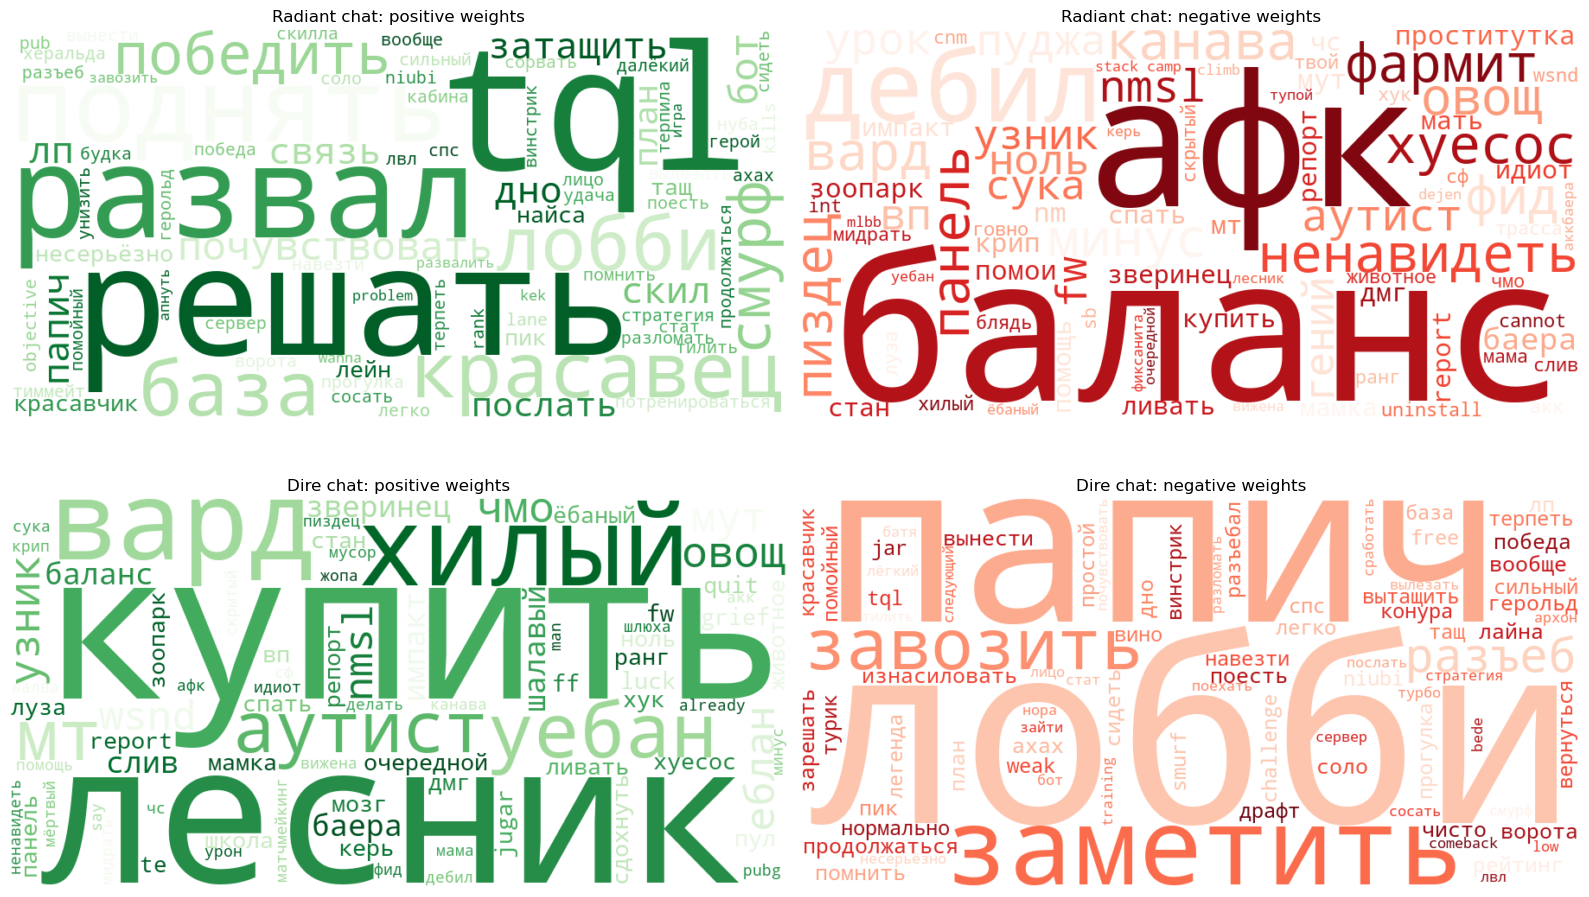

In [7]:
coef = model_adv.coef_.ravel()
base_dim = X_base_train.shape[1]
chat_coef = coef[base_dim:]

feat_r = np.array([f"R:{w}" for w in tfidf_r.get_feature_names_out()])
feat_d = np.array([f"D:{w}" for w in tfidf_d.get_feature_names_out()])
chat_feats = np.concatenate([feat_r, feat_d])

s = pd.Series(chat_coef, index=chat_feats)
s_r = s[s.index.str.startswith("R:")]
s_d = s[s.index.str.startswith("D:")]

s_r.index = s_r.index.str.replace("R:", "", regex=False)
s_d.index = s_d.index.str.replace("D:", "", regex=False)

k = 80
r_pos = s_r[s_r > 0].sort_values(ascending=False).head(k)
r_neg = s_r[s_r < 0].sort_values().head(k)
d_pos = s_d[s_d > 0].sort_values(ascending=False).head(k)
d_neg = s_d[s_d < 0].sort_values().head(k)


def make_wc(freqs, cmap):
    if len(freqs) == 0:
        freqs = {"empty": 1.0}
    return WordCloud(
        width=900, height=450, background_color="white", colormap=cmap
    ).generate_from_frequencies(freqs)


wc_r_pos = make_wc(r_pos.to_dict(), "Greens")
wc_r_neg = make_wc(np.abs(r_neg).to_dict(), "Reds")
wc_d_pos = make_wc(d_pos.to_dict(), "Greens")
wc_d_neg = make_wc(np.abs(d_neg).to_dict(), "Reds")


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(wc_r_pos, interpolation="bilinear")
axes[0, 0].axis("off")
axes[0, 0].set_title("Radiant chat: positive weights")

axes[0, 1].imshow(wc_r_neg, interpolation="bilinear")
axes[0, 1].axis("off")
axes[0, 1].set_title("Radiant chat: negative weights")

axes[1, 0].imshow(wc_d_pos, interpolation="bilinear")
axes[1, 0].axis("off")
axes[1, 0].set_title("Dire chat: positive weights")

axes[1, 1].imshow(wc_d_neg, interpolation="bilinear")
axes[1, 1].axis("off")
axes[1, 1].set_title("Dire chat: negative weights")

plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:** в целом нормально, в neg weights преобладают токсичные слова, а в pos weights преобладают координатные и игровые слова. Что вполне похоже на правду

</div>

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть проблемы — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

(767822, 3)


,match_id,radiant_gold_adv,radiant_exp_adv
0,526846,[ 0 159 452 1904 2100 3290 3290 3290 3290 ...,[ 0 68 658 1397 1435 2118 2118 1923 1923 ...
1,511496,[ 0 -151 -141 12 -165 -151 -151 4 377 ...,[ 0 1 -136 243 -270 -8 -8 -169 -169 ...
2,90272,[],[]


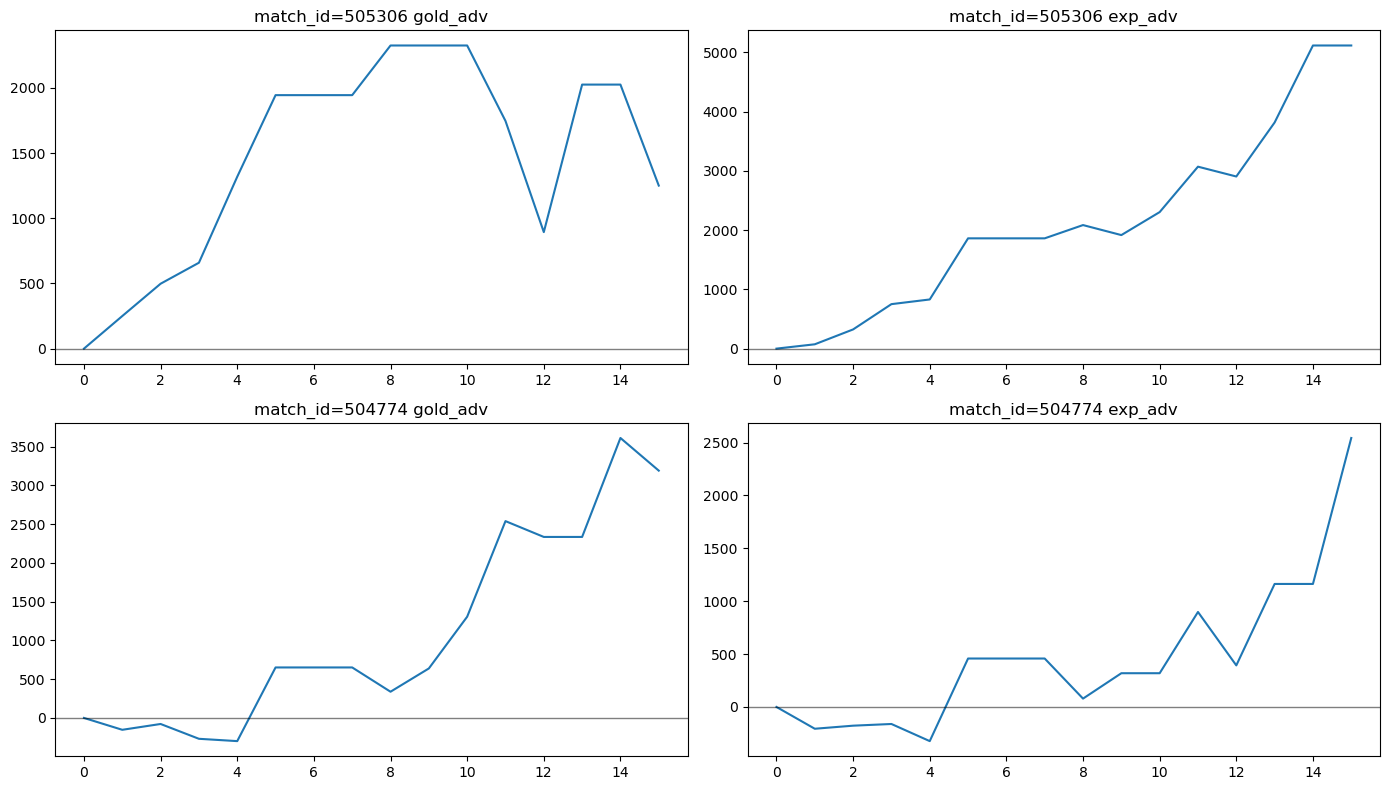

In [8]:
adv_df = pd.read_csv("dota-2-hse-ml-1-course-competition-2026/dota_adv.csv")
print(adv_df.shape)
display(adv_df.head(3))


def parse_adv_seq(x):
    if pd.isna(x):
        return np.array([], dtype=float)
    s = str(x).replace("\n", " ").strip().strip("[]")
    return np.fromstring(s, sep=" ").astype(float)


adv_df["gold_seq"] = adv_df["radiant_gold_adv"].map(parse_adv_seq)
adv_df["exp_seq"] = adv_df["radiant_exp_adv"].map(parse_adv_seq)

non_empty_adv = adv_df[
    (adv_df["gold_seq"].map(len) > 0) & (adv_df["exp_seq"].map(len) > 0)
].copy()

sample = non_empty_adv.sample(2, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (_, row) in enumerate(sample.iterrows()):
    g = row["gold_seq"]
    e = row["exp_seq"]

    axes[i, 0].plot(range(len(g)), g)
    axes[i, 0].axhline(0, color="black", linewidth=1, alpha=0.5)
    axes[i, 0].set_title(f"match_id={row['match_id']} gold_adv")

    axes[i, 1].plot(range(len(e)), e)
    axes[i, 1].axhline(0, color="black", linewidth=1, alpha=0.5)
    axes[i, 1].set_title(f"match_id={row['match_id']} exp_adv")

plt.tight_layout()
plt.show()

In [9]:
adv_df["gold_len"] = adv_df["gold_seq"].map(len)
adv_df["exp_len"] = adv_df["exp_seq"].map(len)

print("empty gold:", (adv_df["gold_len"] == 0).sum())
print("empty exp:", (adv_df["exp_len"] == 0).sum())
print("len mismatch:", (adv_df["gold_len"] != adv_df["exp_len"]).sum())
print("gold_len mode:", adv_df["gold_len"].mode().iloc[0])
print("exp_len mode:", adv_df["exp_len"].mode().iloc[0])

display(adv_df[["gold_len", "exp_len"]].describe())

empty gold: 529783
empty exp: 529783
len mismatch: 0
gold_len mode: 0
exp_len mode: 0


,gold_len,exp_len
count,767822.000000,767822.000000
mean,4.960295,4.960295
std,7.400018,7.400018
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,16.000000,16.000000
max,16.000000,16.000000


в изначальной таблице данные лежат как строки, после парсинга видно, что большая часть матчей не содержит какой-то информации, а непустые имеют длину 16

можно добавить флаг, что статистика отсутствует

Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://docs.pola.rs/api/python/stable/reference/expressions/computation.html) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:** берем last, mean, median, std, а также флаг adv_missing для пустых рядов.

last - итоговое преимущество

mean - средний уровень преимущества

median - устойчивый к выбросам типичный уровень преимущества

std - разброс значений и степень нестабильности advantage
</div>

Также я добавлю scaler потому что он будет стабилизировать оптимизацию и мне просто посоветовали друзья

А также он делает регаляризацию более корректной

In [10]:
def last(arr):
    return arr[-1] if len(arr) > 0 else np.nan


def mean(arr):
    return np.mean(arr) if len(arr) > 0 else np.nan


def median(arr):
    return np.median(arr) if len(arr) > 0 else np.nan


def std(arr):
    return np.std(arr) if len(arr) > 0 else np.nan


adv_features = pd.DataFrame({"match_id": adv_df["match_id"]})
adv_features["adv_missing"] = (
    (adv_df["gold_seq"].map(len) == 0) | (adv_df["exp_seq"].map(len) == 0)
).astype(int)

# gold
adv_features["gold_last"] = adv_df["gold_seq"].map(last)
adv_features["gold_mean"] = adv_df["gold_seq"].map(mean)
adv_features["gold_median"] = adv_df["gold_seq"].map(median)
adv_features["gold_std"] = adv_df["gold_seq"].map(std)

# exp
adv_features["exp_last"] = adv_df["exp_seq"].map(last)
adv_features["exp_mean"] = adv_df["exp_seq"].map(mean)
adv_features["exp_median"] = adv_df["exp_seq"].map(median)
adv_features["exp_std"] = adv_df["exp_seq"].map(std)

adv_cols = [
    "adv_missing",
    "gold_last",
    "gold_mean",
    "gold_median",
    "gold_std",
    "exp_last",
    "exp_mean",
    "exp_median",
    "exp_std",
]


all_ids = pd.Index(base_result.X_train["match_id"]).union(
    base_result.X_test["match_id"]
)
feature_store = pd.DataFrame({"match_id": all_ids})

feature_store = feature_store.drop(
    columns=[c for c in adv_cols if c in feature_store.columns], errors="ignore"
)
feature_store = feature_store.merge(
    adv_features[["match_id"] + adv_cols], on="match_id", how="left"
)

fs_train = base_result.X_train[["match_id"]].merge(
    feature_store, on="match_id", how="left"
)
fs_test = base_result.X_test[["match_id"]].merge(
    feature_store, on="match_id", how="left"
)

fs_train["adv_missing"] = fs_train["adv_missing"].fillna(1)
fs_test["adv_missing"] = fs_test["adv_missing"].fillna(1)

other_adv_cols = [c for c in adv_cols if c != "adv_missing"]
fs_train[other_adv_cols] = fs_train[other_adv_cols].fillna(0.0)
fs_test[other_adv_cols] = fs_test[other_adv_cols].fillna(0.0)

fs_train_raw = fs_train.copy()
fs_test_raw = fs_test.copy()

scaler_adv = StandardScaler()
fs_train_scaled = fs_train.copy()
fs_test_scaled = fs_test.copy()
fs_train_scaled[other_adv_cols] = scaler_adv.fit_transform(fs_train_scaled[other_adv_cols])
fs_test_scaled[other_adv_cols] = scaler_adv.transform(fs_test_scaled[other_adv_cols])

X_stats_train = csr_matrix(fs_train_scaled[adv_cols].to_numpy())
X_stats_test = csr_matrix(fs_test_scaled[adv_cols].to_numpy())


X_final_train = hstack(
    [base_result.X_all_train, X_chat_train, X_stats_train], format="csr"
)
X_final_test = hstack([base_result.X_all_test, X_chat_test, X_stats_test], format="csr")

print("X_stats_train:", X_stats_train.shape)
print("X_final_train:", X_final_train.shape)

X_stats_train: (641090, 9)
X_final_train: (641090, 7795)


Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [11]:
order = pd.to_datetime(base_result.X_train["date"]).sort_values().index.to_numpy()

X_df = base_result.X_train.iloc[order].reset_index(drop=True)
y_df = base_result.y_train.iloc[order].reset_index(drop=True)

chat_ord = train_chat.iloc[order].reset_index(drop=True)

_, X_hero_train_all, _ = build_hero_matrices(
    base_result.player_df_clean,
    train_match_ids=base_result.X_train["match_id"],
    test_match_ids=base_result.X_test["match_id"],
)
X_hero_ord = X_hero_train_all[order]

fs_train_ord = fs_train_raw.iloc[order].reset_index(drop=True)
adv_cols = [
    "adv_missing",
    "gold_last",
    "gold_mean",
    "gold_median",
    "gold_std",
    "exp_last",
    "exp_mean",
    "exp_median",
    "exp_std",
]
other_adv_cols = [c for c in adv_cols if c != "adv_missing"]

ts = TimeSeriesSplit(n_splits=5)
scores = []

for tr_idx, val_idx in ts.split(np.arange(len(X_df))):
    X_tr_df = X_df.iloc[tr_idx]
    X_val_df = X_df.iloc[val_idx]
    y_tr = y_df.iloc[tr_idx]
    y_val = y_df.iloc[val_idx]

    # region+mmr
    rm_art = fit_region_mmr_artifacts(X_tr_df, y_tr)
    X_rm_tr = transform_region_mmr(X_tr_df, rm_art)
    X_rm_val = transform_region_mmr(X_val_df, rm_art)

    # tfidf
    tfidf_r = TfidfVectorizer(
        ngram_range=(1, 2), min_df=5, max_df=0.98, sublinear_tf=True
    )
    tfidf_d = TfidfVectorizer(
        ngram_range=(1, 2), min_df=5, max_df=0.98, sublinear_tf=True
    )
    X_r_tr = tfidf_r.fit_transform(chat_ord.iloc[tr_idx]["radiant_chat"])
    X_d_tr = tfidf_d.fit_transform(chat_ord.iloc[tr_idx]["dire_chat"])
    X_r_val = tfidf_r.transform(chat_ord.iloc[val_idx]["radiant_chat"])
    X_d_val = tfidf_d.transform(chat_ord.iloc[val_idx]["dire_chat"])

    # scaler
    adv_tr = fs_train_ord.iloc[tr_idx][adv_cols].copy()
    adv_val = fs_train_ord.iloc[val_idx][adv_cols].copy()

    scaler_fold = StandardScaler()
    adv_tr[other_adv_cols] = scaler_fold.fit_transform(
        adv_tr[other_adv_cols].fillna(0.0)
    )
    adv_val[other_adv_cols] = scaler_fold.transform(adv_val[other_adv_cols].fillna(0.0))
    adv_tr["adv_missing"] = adv_tr["adv_missing"].fillna(1)
    adv_val["adv_missing"] = adv_val["adv_missing"].fillna(1)

    X_stats_tr = csr_matrix(adv_tr.to_numpy())
    X_stats_val = csr_matrix(adv_val.to_numpy())

    X_fold_tr = hstack(
        [X_rm_tr, X_hero_ord[tr_idx], X_r_tr, X_d_tr, X_stats_tr], format="csr"
    )
    X_fold_val = hstack(
        [X_rm_val, X_hero_ord[val_idx], X_r_val, X_d_val, X_stats_val], format="csr"
    )

    clf = make_best_logreg()
    clf.fit(X_fold_tr, y_tr)
    p_val = clf.predict_proba(X_fold_val)[:, 1]
    scores.append(gini(y_val, p_val))


print(f"all gini: {np.mean(scores):.6f} ± {np.std(scores):.6f}")
print("folds:", [round(s, 6) for s in scores])


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1600 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1600).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1600 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1600).
You might also want to scale the data as shown in:
    https

all gini: 0.408479 ± 0.003476
folds: [0.40292, 0.40748, 0.407589, 0.412218, 0.412185]


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1600 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1600).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
rm_art = fit_region_mmr_artifacts(base_result.X_train, base_result.y_train)
X_rm_train = transform_region_mmr(base_result.X_train, rm_art)
X_rm_test = transform_region_mmr(base_result.X_test, rm_art)

_, X_hero_train, X_hero_test = build_hero_matrices(
    base_result.player_df_clean,
    train_match_ids=base_result.X_train["match_id"],
    test_match_ids=base_result.X_test["match_id"],
)

tfidf_r = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.98, sublinear_tf=True)
tfidf_d = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.98, sublinear_tf=True)

X_r_train = tfidf_r.fit_transform(train_chat["radiant_chat"])
X_d_train = tfidf_d.fit_transform(train_chat["dire_chat"])
X_r_test = tfidf_r.transform(test_chat["radiant_chat"])
X_d_test = tfidf_d.transform(test_chat["dire_chat"])

adv_cols = [
    "adv_missing",
    "gold_last",
    "gold_mean",
    "gold_median",
    "gold_std",
    "exp_last",
    "exp_mean",
    "exp_median",
    "exp_std",
]
other_adv_cols = [c for c in adv_cols if c != "adv_missing"]

fs_train_full = fs_train_raw.copy()
fs_test_full = fs_test_raw.copy()

scaler_adv_full = StandardScaler()
fs_train_full[other_adv_cols] = scaler_adv_full.fit_transform(
    fs_train_full[other_adv_cols].fillna(0.0)
)
fs_test_full[other_adv_cols] = scaler_adv_full.transform(
    fs_test_full[other_adv_cols].fillna(0.0)
)

X_stats_train = csr_matrix(fs_train_full[adv_cols].to_numpy())
X_stats_test = csr_matrix(fs_test_full[adv_cols].to_numpy())


X_final_train = hstack(
    [X_rm_train, X_hero_train, X_r_train, X_d_train, X_stats_train], format="csr"
)
X_final_test = hstack(
    [X_rm_test, X_hero_test, X_r_test, X_d_test, X_stats_test], format="csr"
)

print("X_final_train:", X_final_train.shape)
print("X_final_test :", X_final_test.shape)

model_final = make_best_logreg()
model_final.fit(X_final_train, base_result.y_train)

pred_test = model_final.predict_proba(X_final_test)[:, 1]
submission_final = pd.DataFrame(
    {
        "ID": base_result.X_test["match_id"].values,
        "Value": pred_test,
    }
)
submission_final.to_csv("submission_final.csv", index=False)
print("saved: submission_final.csv")

X_final_train: (641090, 7795)
X_final_test : (59748, 7795)
saved: submission_final.csv


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1600 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1600).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее - она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:** тренд нужен для анализа направления изменения преимущества, так мы сможем выявить команды которые стабильно ведут игру, а не случайно выигрывают. Да, она полезна, тк тренд устойчивее и дешево.

</div>

Агрегации можно делать несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#d18753">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $`\alpha`$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [13]:
from typing import Iterable

class TrendTransformer:

    def __init__(self, columns: Iterable[str]):
        self.columns = columns

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        # ヾ(⌐■_■)ノ♪ your code here
        raise Exception("transform method not implemented")

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [14]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на МОП? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Как конкретно он будет выглядеть — зависит полностью от вас. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

In [15]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- сохранялись метрики

Сделайте и продемонстрируйте

In [16]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`. 

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [17]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [18]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#d18753">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#d18753">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#d18753">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#d18753">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #7298ce; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

In [19]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.